# Movie Rating Intelligence

A data analytics and machine learning project to understand what characteristics are associated with movie ratings, build an explainable rating prediction model, and later turn the model into a simple interactive application.

## Project Objectives

1. Explore patterns in movie ratings, genres, directors, actors, year, duration, and votes.
2. Build a clean rating prediction workflow using understandable machine learning models.
3. Identify which movie characteristics influence predictions the most.
4. Use explainable AI techniques to understand individual predictions.
5. Build a simple Streamlit application where a user can enter movie characteristics and receive an estimated rating.

## 1. Import Libraries

Libraries used for data analysis, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load and Inspect the Dataset

The IMDb Movies India dataset is loaded and inspected to understand its structure, available features, missing values, and data types before performing any cleaning or analysis.

In [2]:
DATA_PATH = "../data/IMDb Movies India.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

===== DATASET INFORMATION =====
<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB

===== MISSING VALUES =====
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [4]:
print("===== UNIQUE VALUES =====")

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

===== UNIQUE VALUES =====
Name: 13838 unique values
Year: 102 unique values
Duration: 182 unique values
Genre: 485 unique values
Rating: 84 unique values
Votes: 2034 unique values
Director: 5938 unique values
Actor 1: 4718 unique values
Actor 2: 4891 unique values
Actor 3: 4820 unique values


## 3. Data Cleaning

The raw dataset contains numerical information stored as text and a substantial number of missing values.

The following initial cleaning steps are performed:

- Extract the numerical year from `Year`
- Convert `Duration` from text such as `120 min` to a numerical value
- Convert `Votes` to a numerical value by removing commas
- Remove duplicate movie records
- Separate movies with known ratings from movies without rating labels

In [5]:
movies = df.copy()

# Remove duplicate rows
movies = movies.drop_duplicates()

# Clean Year
movies['Year'] = (
    movies['Year']
    .str.extract(r'(\d{4})')[0]
)

movies['Year'] = pd.to_numeric(
    movies['Year'],
    errors='coerce'
)

# Clean Duration
movies['Duration'] = (
    movies['Duration']
    .str.extract(r'(\d+)')[0]
)

movies['Duration'] = pd.to_numeric(
    movies['Duration'],
    errors='coerce'
)

# Clean Votes
movies['Votes'] = (
    movies['Votes']
    .str.replace(',', '', regex=False)
)

movies['Votes'] = pd.to_numeric(
    movies['Votes'],
    errors='coerce'
)

print("Original rows :", len(df))
print("After removing duplicates :", len(movies))

display(
    movies[['Year', 'Duration', 'Votes', 'Rating']].head()
)

Original rows : 15509
After removing duplicates : 15503


,Year,Duration,Votes,Rating
0,NaN,NaN,NaN,NaN
1,2019.0,109.0,8.0,7.0
2,2021.0,90.0,NaN,NaN
3,2019.0,110.0,35.0,4.4
4,2010.0,105.0,NaN,NaN


In [6]:
rated_movies = movies[
    movies['Rating'].notna()
].copy()

print("===== RATING AVAILABILITY =====")
print(f"Total Movies         : {len(movies)}")
print(f"Movies With Rating   : {len(rated_movies)}")
print(f"Movies Without Rating: {movies['Rating'].isna().sum()}")

print("\n===== CLEANED DATA TYPES =====")
print(
    rated_movies[
        ['Year', 'Duration', 'Votes', 'Rating']
    ].dtypes
)

print("\n===== MISSING VALUES IN RATED MOVIES =====")
print(rated_movies.isnull().sum())

===== RATING AVAILABILITY =====
Total Movies         : 15503
Movies With Rating   : 7919
Movies Without Rating: 7584

===== CLEANED DATA TYPES =====
Year        float64
Duration    float64
Votes       float64
Rating      float64
dtype: object

===== MISSING VALUES IN RATED MOVIES =====
Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64


In [8]:
print("===== DURATION ANALYSIS =====")

print(rated_movies['Duration'].describe())

print(
    "\nMovies with Duration:",
    rated_movies['Duration'].notna().sum()
)

print(
    "Movies without Duration:",
    rated_movies['Duration'].isna().sum()
)

print(
    "Missing Percentage:",
    round(rated_movies['Duration'].isna().mean() * 100, 2),
    "%"
)

===== DURATION ANALYSIS =====
count    5851.000000
mean      132.294480
std        26.555826
min        21.000000
25%       117.000000
50%       134.000000
75%       150.000000
max       321.000000
Name: Duration, dtype: float64

Movies with Duration: 5851
Movies without Duration: 2068
Missing Percentage: 26.11 %


In [9]:
categorical_columns = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

rated_movies[categorical_columns] = (
    rated_movies[categorical_columns]
    .fillna('Unknown')
)

print("===== MISSING VALUES AFTER CATEGORICAL CLEANING =====")
print(rated_movies.isnull().sum())

===== MISSING VALUES AFTER CATEGORICAL CLEANING =====
Name           0
Year           0
Duration    2068
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64


In [10]:
print("===== CLEANED DATA VALIDATION =====")

print("Duplicate rows:", rated_movies.duplicated().sum())

print("\n===== NUMERICAL SUMMARY =====")
print(
    rated_movies[
        ['Year', 'Duration', 'Votes', 'Rating']
    ].describe()
)

print("\n===== INVALID VALUE CHECK =====")
print("Non-positive Duration:",
      (rated_movies['Duration'].dropna() <= 0).sum())

print("Negative Votes:",
      (rated_movies['Votes'] < 0).sum())

print("Ratings outside 0-10:",
      ((rated_movies['Rating'] < 0) |
       (rated_movies['Rating'] > 10)).sum())

===== CLEANED DATA VALIDATION =====
Duplicate rows: 0

===== NUMERICAL SUMMARY =====
              Year     Duration          Votes       Rating
count  7919.000000  5851.000000    7919.000000  7919.000000
mean   1993.321758   132.294480    1938.520394     5.841621
std      20.463770    26.555826   11602.415952     1.381777
min    1917.000000    21.000000       5.000000     1.100000
25%    1979.500000   117.000000      16.000000     4.900000
50%    1997.000000   134.000000      55.000000     6.000000
75%    2011.000000   150.000000     404.000000     6.800000
max    2021.000000   321.000000  591417.000000    10.000000

===== INVALID VALUE CHECK =====
Non-positive Duration: 0
Negative Votes: 0
Ratings outside 0-10: 0


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand meaningful patterns in movie ratings and the characteristics associated with them.

The analysis begins with the distribution of IMDb ratings to understand the overall rating pattern before examining relationships with year, genre, duration, votes, directors, and actors.

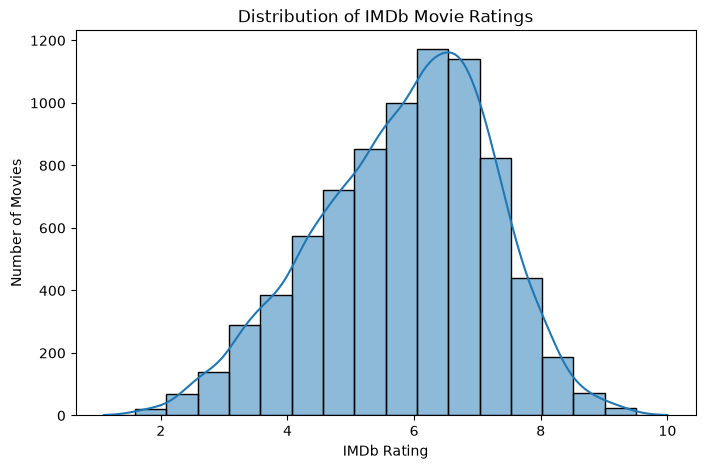

===== RATING SUMMARY =====
count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=rated_movies,
    x='Rating',
    bins=18,
    kde=True
)

plt.title('Distribution of IMDb Movie Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Movies')

plt.show()

print("===== RATING SUMMARY =====")
print(rated_movies['Rating'].describe())

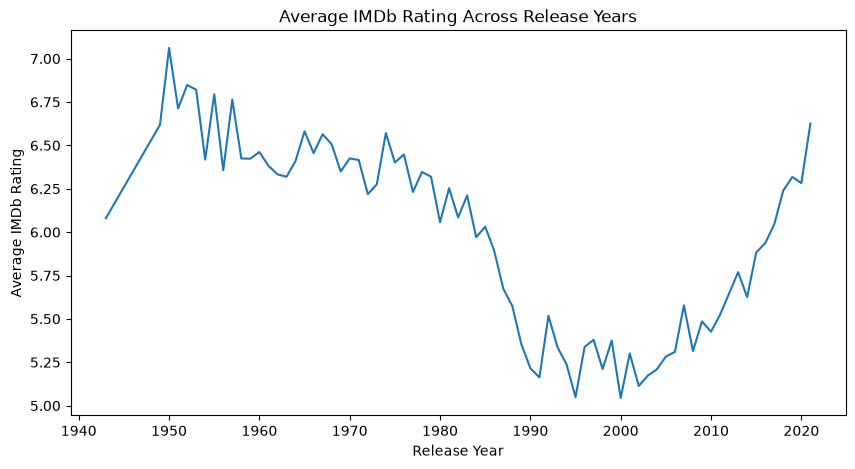

,Year,Average_Rating,Movie_Count
82,2012.0,5.646429,168
83,2013.0,5.769271,192
84,2014.0,5.625134,187
85,2015.0,5.882915,199
86,2016.0,5.936453,203
87,2017.0,6.044915,236
88,2018.0,6.239912,228
89,2019.0,6.317671,249
90,2020.0,6.282635,167
91,2021.0,6.625641,78


In [12]:
yearly_ratings = (
    rated_movies
    .groupby('Year')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Movie_Count=('Rating', 'count')
    )
    .reset_index()
)

# Keep years with at least 20 rated movies
yearly_ratings_filtered = yearly_ratings[
    yearly_ratings['Movie_Count'] >= 20
]

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_ratings_filtered,
    x='Year',
    y='Average_Rating'
)

plt.title('Average IMDb Rating Across Release Years')
plt.xlabel('Release Year')
plt.ylabel('Average IMDb Rating')

plt.show()

display(yearly_ratings_filtered.tail(10))

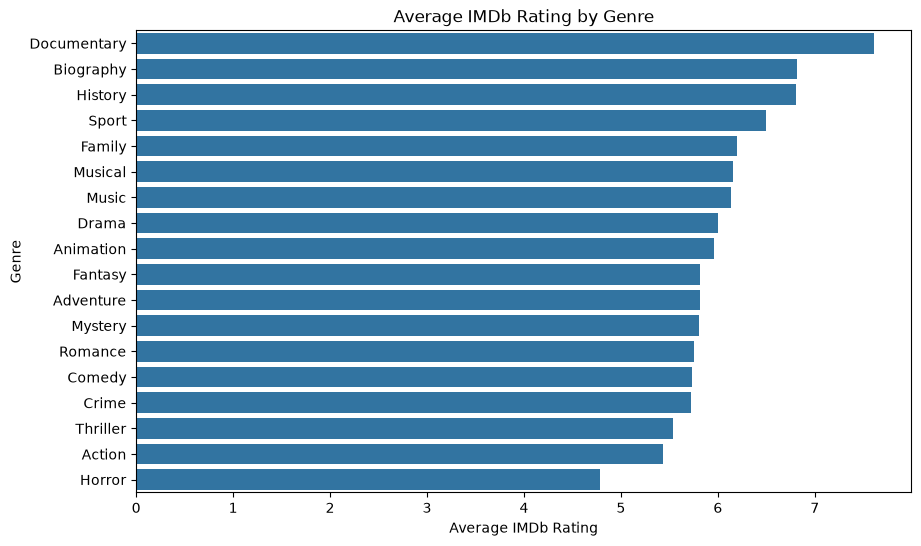

,Genre,Average_Rating,Movie_Count
6,Documentary,7.613287,143
3,Biography,6.819718,142
10,History,6.804688,128
18,Sport,6.494118,51
8,Family,6.195173,663
13,Musical,6.156627,498
12,Music,6.137705,61
7,Drama,5.998558,4924
2,Animation,5.956164,73
9,Fantasy,5.819512,205


In [13]:
genre_data = rated_movies[
    rated_movies['Genre'] != 'Unknown'
][['Genre', 'Rating']].copy()

# Split movies with multiple genres
genre_data['Genre'] = genre_data['Genre'].str.split(',')

genre_data = genre_data.explode('Genre')

genre_data['Genre'] = genre_data['Genre'].str.strip()

genre_summary = (
    genre_data
    .groupby('Genre')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Movie_Count=('Rating', 'count')
    )
    .reset_index()
)

# Keep genres represented by at least 50 movies
genre_summary_filtered = (
    genre_summary[
        genre_summary['Movie_Count'] >= 50
    ]
    .sort_values('Average_Rating', ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_summary_filtered,
    x='Average_Rating',
    y='Genre'
)

plt.title('Average IMDb Rating by Genre')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Genre')

plt.show()

display(genre_summary_filtered)

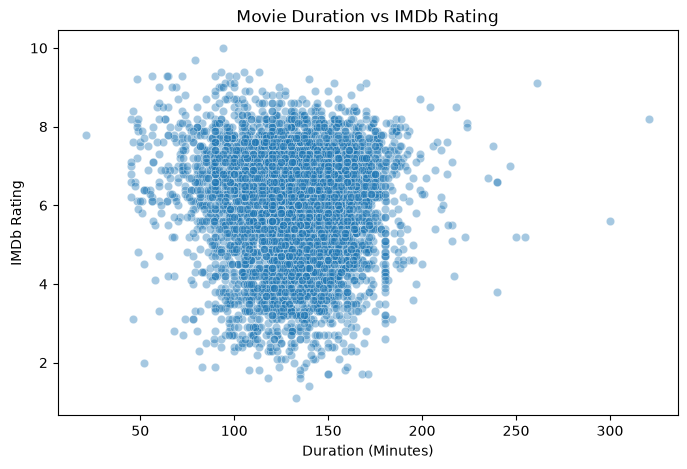

Correlation between Duration and Rating: -0.031


In [14]:
duration_data = rated_movies[
    rated_movies['Duration'].notna()
]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=duration_data,
    x='Duration',
    y='Rating',
    alpha=0.4
)

plt.title('Movie Duration vs IMDb Rating')
plt.xlabel('Duration (Minutes)')
plt.ylabel('IMDb Rating')

plt.show()

duration_rating_corr = (
    duration_data['Duration']
    .corr(duration_data['Rating'])
)

print(
    "Correlation between Duration and Rating:",
    round(duration_rating_corr, 3)
)

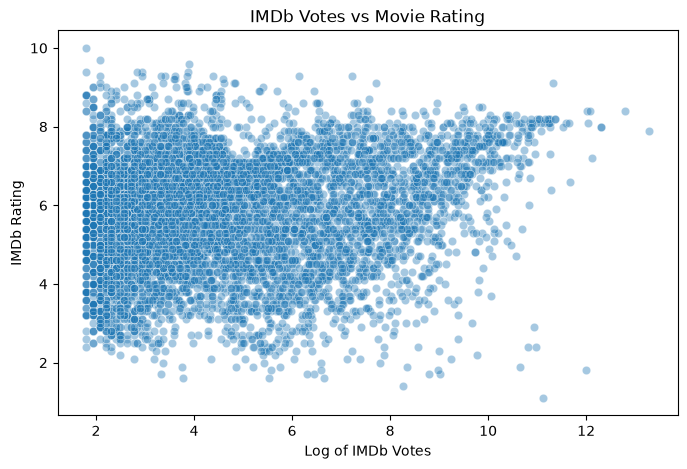

Correlation between Votes and Rating: 0.127


In [15]:
vote_data = rated_movies.copy()

vote_data['Log_Votes'] = np.log1p(
    vote_data['Votes']
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=vote_data,
    x='Log_Votes',
    y='Rating',
    alpha=0.4
)

plt.title('IMDb Votes vs Movie Rating')
plt.xlabel('Log of IMDb Votes')
plt.ylabel('IMDb Rating')

plt.show()

votes_rating_corr = (
    vote_data['Votes']
    .corr(vote_data['Rating'])
)

print(
    "Correlation between Votes and Rating:",
    round(votes_rating_corr, 3)
)

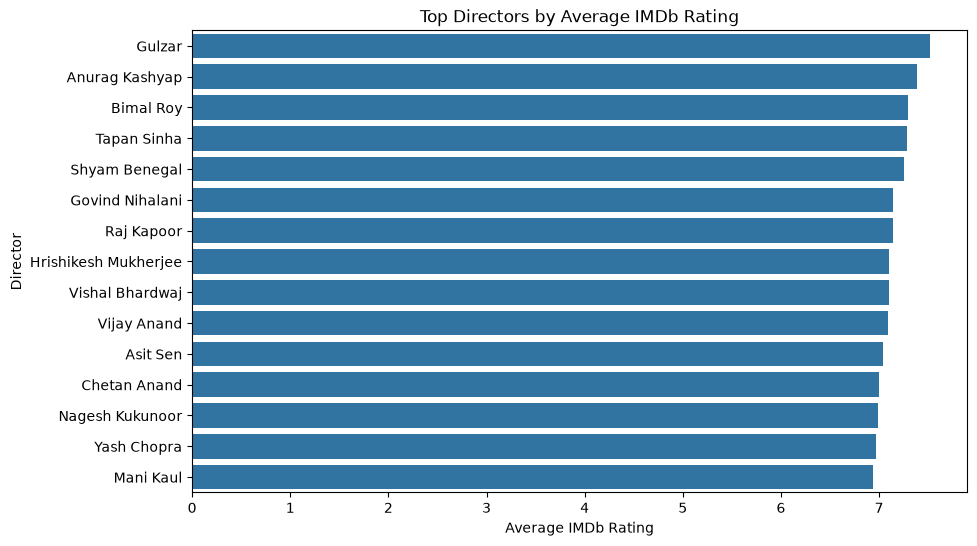

,Director,Average_Rating,Movie_Count
869,Gulzar,7.521053,19
299,Anurag Kashyap,7.385714,14
525,Bimal Roy,7.293750,16
2885,Tapan Sinha,7.280000,10
2661,Shyam Benegal,7.250000,22
861,Govind Nihalani,7.146154,13
2010,Raj Kapoor,7.145455,11
962,Hrishikesh Mukherjee,7.102381,42
3069,Vishal Bhardwaj,7.100000,10
3002,Vijay Anand,7.093750,16


In [16]:
director_data = rated_movies[
    rated_movies['Director'] != 'Unknown'
]

director_summary = (
    director_data
    .groupby('Director')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Movie_Count=('Rating', 'count')
    )
    .reset_index()
)

director_summary_filtered = (
    director_summary[
        director_summary['Movie_Count'] >= 10
    ]
    .sort_values(
        'Average_Rating',
        ascending=False
    )
)

top_directors = director_summary_filtered.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_directors,
    x='Average_Rating',
    y='Director'
)

plt.title('Top Directors by Average IMDb Rating')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Director')

plt.show()

display(top_directors)

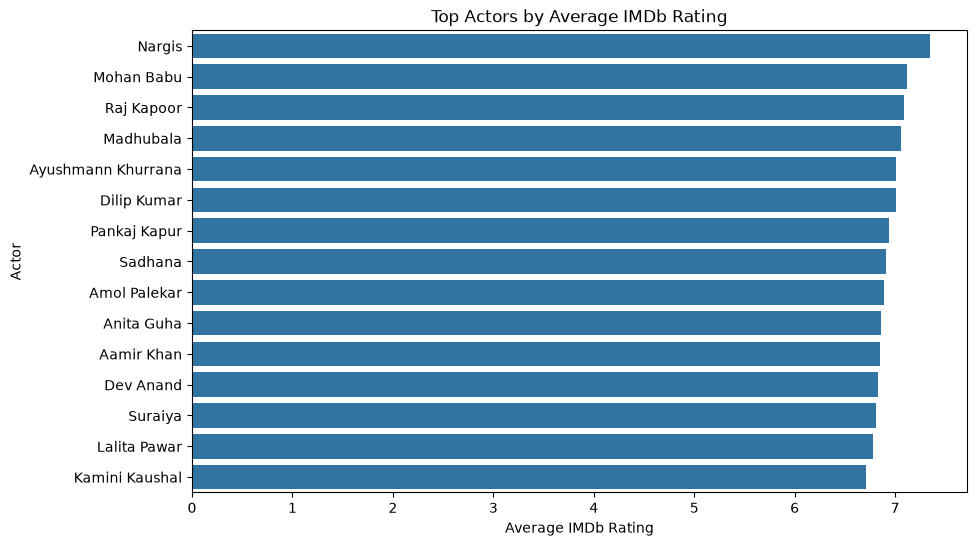

,Actor,Average_Rating,Movie_Count
3331,Nargis,7.347368,38
3112,Mohan Babu,7.120000,15
4025,Raj Kapoor,7.085455,55
2743,Madhubala,7.061702,47
940,Ayushmann Khurrana,7.006667,15
1482,Dilip Kumar,7.003774,53
3621,Pankaj Kapur,6.937500,16
4567,Sadhana,6.910714,28
451,Amol Palekar,6.891667,24
556,Anita Guha,6.856250,16


In [17]:
actor_data = pd.concat([
    rated_movies[['Actor 1', 'Rating']]
        .rename(columns={'Actor 1': 'Actor'}),

    rated_movies[['Actor 2', 'Rating']]
        .rename(columns={'Actor 2': 'Actor'}),

    rated_movies[['Actor 3', 'Rating']]
        .rename(columns={'Actor 3': 'Actor'})
])

actor_data = actor_data[
    actor_data['Actor'] != 'Unknown'
]

actor_summary = (
    actor_data
    .groupby('Actor')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Movie_Count=('Rating', 'count')
    )
    .reset_index()
)

actor_summary_filtered = (
    actor_summary[
        actor_summary['Movie_Count'] >= 15
    ]
    .sort_values(
        'Average_Rating',
        ascending=False
    )
)

top_actors = actor_summary_filtered.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_actors,
    x='Average_Rating',
    y='Actor'
)

plt.title('Top Actors by Average IMDb Rating')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Actor')

plt.show()

display(top_actors)

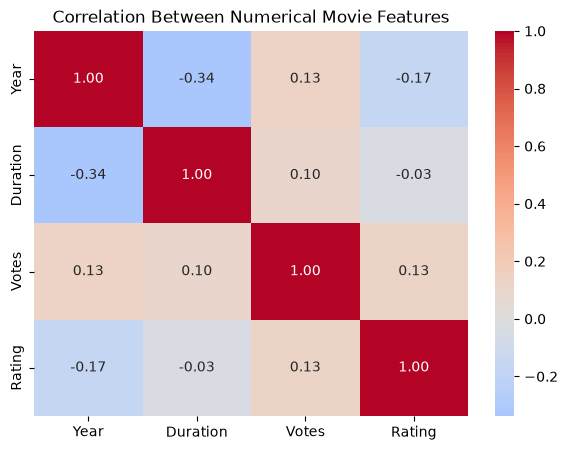

,Year,Duration,Votes,Rating
Year,1.000000,-0.337425,0.129016,-0.166673
Duration,-0.337425,1.000000,0.099660,-0.031093
Votes,0.129016,0.099660,1.000000,0.126635
Rating,-0.166673,-0.031093,0.126635,1.000000


In [18]:
numerical_features = rated_movies[
    ['Year', 'Duration', 'Votes', 'Rating']
]

correlation_matrix = numerical_features.corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Numerical Movie Features')

plt.show()

display(correlation_matrix)

## 5. Preparing Data for Machine Learning

The next stage prepares the rated movie data for regression modeling.

`Rating` is used as the target variable. `Name` is excluded because it mainly acts as a movie identifier rather than a generalizable movie characteristic.

The remaining numerical and categorical features will be prepared carefully for model training. The train-test split is performed before learning any imputation or encoding information from the data to reduce the risk of data leakage.

In [19]:
model_data = rated_movies.copy()

# Movie title is not used as a predictive feature
model_data = model_data.drop(columns=['Name'])

X = model_data.drop(columns=['Rating'])
y = model_data['Rating']

print("===== MODELING DATA =====")
print("Feature Data Shape:", X.shape)
print("Target Shape:", y.shape)

print("\n===== FEATURES =====")
print(X.columns.tolist())

print("\n===== TARGET =====")
print("Rating")

===== MODELING DATA =====
Feature Data Shape: (7919, 8)
Target Shape: (7919,)

===== FEATURES =====
['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

===== TARGET =====
Rating


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("===== TRAIN-TEST SPLIT =====")
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nTraining Percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing Percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

===== TRAIN-TEST SPLIT =====
Training Features : (6335, 8)
Testing Features  : (1584, 8)
Training Target   : (6335,)
Testing Target    : (1584,)

Training Percentage: 80.0 %
Testing Percentage: 20.0 %


In [21]:
# Work on copies
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Learn median Duration from training data only
duration_median = X_train_processed['Duration'].median()

# Apply the same value to training and test data
X_train_processed['Duration'] = (
    X_train_processed['Duration']
    .fillna(duration_median)
)

X_test_processed['Duration'] = (
    X_test_processed['Duration']
    .fillna(duration_median)
)

# Log-transform Votes
X_train_processed['Log_Votes'] = np.log1p(
    X_train_processed['Votes']
)

X_test_processed['Log_Votes'] = np.log1p(
    X_test_processed['Votes']
)

# Remove original Votes column
X_train_processed = X_train_processed.drop(
    columns=['Votes']
)

X_test_processed = X_test_processed.drop(
    columns=['Votes']
)

print("===== NUMERICAL PREPROCESSING =====")
print("Training Duration Median:", duration_median)

print(
    "Missing Duration in Training:",
    X_train_processed['Duration'].isna().sum()
)

print(
    "Missing Duration in Testing:",
    X_test_processed['Duration'].isna().sum()
)

print("\nTraining Shape:", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

print("\nCurrent Features:")
print(X_train_processed.columns.tolist())

===== NUMERICAL PREPROCESSING =====
Training Duration Median: 135.0
Missing Duration in Training: 0
Missing Duration in Testing: 0

Training Shape: (6335, 8)
Testing Shape : (1584, 8)

Current Features:
['Year', 'Duration', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Log_Votes']


In [22]:
categorical_columns = [
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

# Frequency encode Director and Actor columns
for column in categorical_columns:

    frequency_map = (
        X_train_processed[column]
        .value_counts(normalize=True)
    )

    X_train_processed[column + '_Frequency'] = (
        X_train_processed[column]
        .map(frequency_map)
        .fillna(0)
    )

    X_test_processed[column + '_Frequency'] = (
        X_test_processed[column]
        .map(frequency_map)
        .fillna(0)
    )


# Get individual genres from training data only
training_genres = set()

for genres in X_train_processed['Genre']:
    for genre in genres.split(','):
        training_genres.add(genre.strip())

training_genres = sorted(training_genres)


# Create binary genre features
for genre in training_genres:

    column_name = 'Genre_' + genre.replace(' ', '_')

    X_train_processed[column_name] = (
        X_train_processed['Genre']
        .apply(
            lambda x: int(
                genre in [g.strip() for g in x.split(',')]
            )
        )
    )

    X_test_processed[column_name] = (
        X_test_processed['Genre']
        .apply(
            lambda x: int(
                genre in [g.strip() for g in x.split(',')]
            )
        )
    )


# Remove original categorical columns
X_train_processed = X_train_processed.drop(
    columns=[
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3'
    ]
)

X_test_processed = X_test_processed.drop(
    columns=[
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3'
    ]
)


print("===== CATEGORICAL ENCODING =====")

print("Number of Genres:", len(training_genres))
print("Genres:")
print(training_genres)

print("\nTraining Shape:", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

print("\nFinal Features:")
print(X_train_processed.columns.tolist())

print(
    "\nMissing Values in Training:",
    X_train_processed.isnull().sum().sum()
)

print(
    "Missing Values in Testing:",
    X_test_processed.isnull().sum().sum()
)

===== CATEGORICAL ENCODING =====
Number of Genres: 23
Genres:
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'Unknown', 'War', 'Western']

Training Shape: (6335, 30)
Testing Shape : (1584, 30)

Final Features:
['Year', 'Duration', 'Log_Votes', 'Director_Frequency', 'Actor 1_Frequency', 'Actor 2_Frequency', 'Actor 3_Frequency', 'Genre_Action', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Documentary', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy', 'Genre_History', 'Genre_Horror', 'Genre_Music', 'Genre_Musical', 'Genre_Mystery', 'Genre_News', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Sport', 'Genre_Thriller', 'Genre_Unknown', 'Genre_War', 'Genre_Western']

Missing Values in Training: 0
Missing Values in Testing: 0


## 6. Baseline Regression Model

A Linear Regression model is used as the baseline for movie rating prediction. Starting with a simple and interpretable model provides a reference point for evaluating whether more flexible models offer meaningful improvements.

Model performance is evaluated using:

- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual ratings.
- **RMSE (Root Mean Squared Error):** measures prediction error while giving more weight to larger errors.
- **R²:** measures how much of the variation in movie ratings is explained by the model.

In [23]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_processed
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("===== LINEAR REGRESSION BASELINE =====")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

===== LINEAR REGRESSION BASELINE =====
MAE : 0.9205
RMSE: 1.1816
R²  : 0.249


## 7. Model Comparison

The baseline Linear Regression model is compared with two tree-based regression models: Random Forest and Gradient Boosting.

The same training and testing data are used for all models so that their performance can be compared fairly using MAE, RMSE, and R².

In [24]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test_processed
)

gb_predictions = gradient_boosting_model.predict(
    X_test_processed
)


def evaluate_model(y_true, predictions):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return mae, rmse, r2


rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions
)

gb_mae, gb_rmse, gb_r2 = evaluate_model(
    y_test,
    gb_predictions
)


model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R²': [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results = model_results.sort_values(
    'MAE'
).reset_index(drop=True)

print("===== MODEL COMPARISON =====")

display(
    model_results.round(4)
)

===== MODEL COMPARISON =====


,Model,MAE,RMSE,R²
0,Gradient Boosting,0.8036,1.0634,0.3918
1,Random Forest,0.8070,1.0750,0.3785
2,Linear Regression,0.9205,1.1816,0.2490


## 8. Error Analysis

Gradient Boosting achieved the strongest overall performance among the tested models, so it is selected for further analysis.

Prediction errors are examined to understand where the model performs well and where its estimates differ substantially from actual IMDb ratings. This includes comparing predicted and actual ratings, examining residuals, and identifying movies with the largest prediction errors.

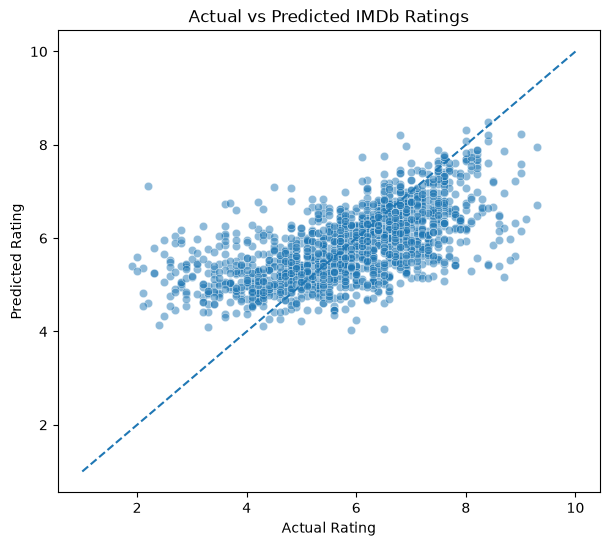

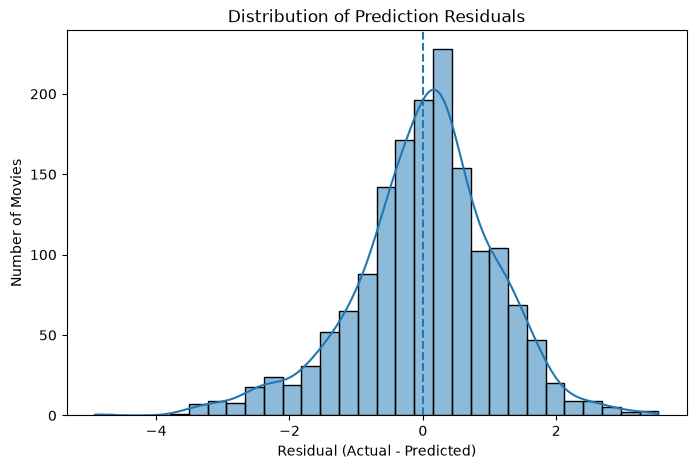

===== LARGEST PREDICTION ERRORS =====


,Name,Rating,Predicted_Rating,Absolute_Error
13481,Student of the Year 2,2.2,7.120,4.920
14155,The Legend of Drona,2.0,5.595,3.595
8791,Man on Mission Taqatwar,8.7,5.167,3.533
5523,Hari Puttar: A Comedy of Terrors,1.9,5.403,3.503
2526,Boom,2.3,5.780,3.480
2077,Bhadaas,2.5,5.968,3.468
6548,Jannat E Milan,2.8,6.165,3.365
7394,Kashmira,2.7,6.046,3.346
6346,Jackpot,2.0,5.305,3.305
8437,Maa Santoshi Maa,8.9,5.616,3.284


In [25]:
final_model = gradient_boosting_model
final_predictions = gb_predictions

# Create error analysis dataframe
error_analysis = rated_movies.loc[
    X_test.index,
    ['Name', 'Rating']
].copy()

error_analysis['Predicted_Rating'] = final_predictions

error_analysis['Residual'] = (
    error_analysis['Rating']
    - error_analysis['Predicted_Rating']
)

error_analysis['Absolute_Error'] = (
    error_analysis['Residual'].abs()
)

# Predicted vs Actual
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=error_analysis,
    x='Rating',
    y='Predicted_Rating',
    alpha=0.5
)

plt.plot(
    [1, 10],
    [1, 10],
    linestyle='--'
)

plt.title('Actual vs Predicted IMDb Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')

plt.show()


# Residual distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    error_analysis['Residual'],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title('Distribution of Prediction Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Number of Movies')

plt.show()


print("===== LARGEST PREDICTION ERRORS =====")

largest_errors = (
    error_analysis
    .sort_values(
        'Absolute_Error',
        ascending=False
    )
    .head(10)
)

display(
    largest_errors[
        [
            'Name',
            'Rating',
            'Predicted_Rating',
            'Absolute_Error'
        ]
    ].round(3)
)

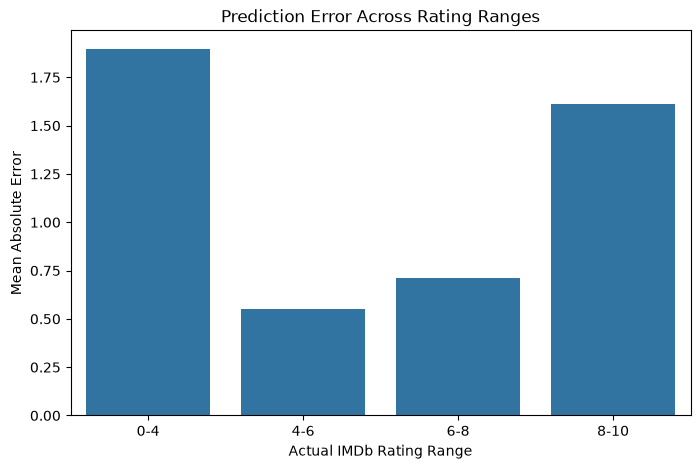

,Rating_Range,Movie_Count,Mean_Absolute_Error
0,0-4,166,1.897
1,4-6,632,0.549
2,6-8,728,0.710
3,8-10,58,1.614


In [26]:
error_analysis['Rating_Range'] = pd.cut(
    error_analysis['Rating'],
    bins=[0, 4, 6, 8, 10],
    labels=[
        '0-4',
        '4-6',
        '6-8',
        '8-10'
    ],
    include_lowest=True
)

rating_range_errors = (
    error_analysis
    .groupby(
        'Rating_Range',
        observed=False
    )
    .agg(
        Movie_Count=('Rating', 'count'),
        Mean_Absolute_Error=('Absolute_Error', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_range_errors,
    x='Rating_Range',
    y='Mean_Absolute_Error'
)

plt.title('Prediction Error Across Rating Ranges')
plt.xlabel('Actual IMDb Rating Range')
plt.ylabel('Mean Absolute Error')

plt.show()

display(
    rating_range_errors.round(3)
)

## 9. Feature Importance

The Gradient Boosting model provides feature importance scores that indicate which input features were most useful for its predictions.

These scores describe predictive importance within the trained model. They do not imply that a feature causes a movie to receive a higher or lower IMDb rating.

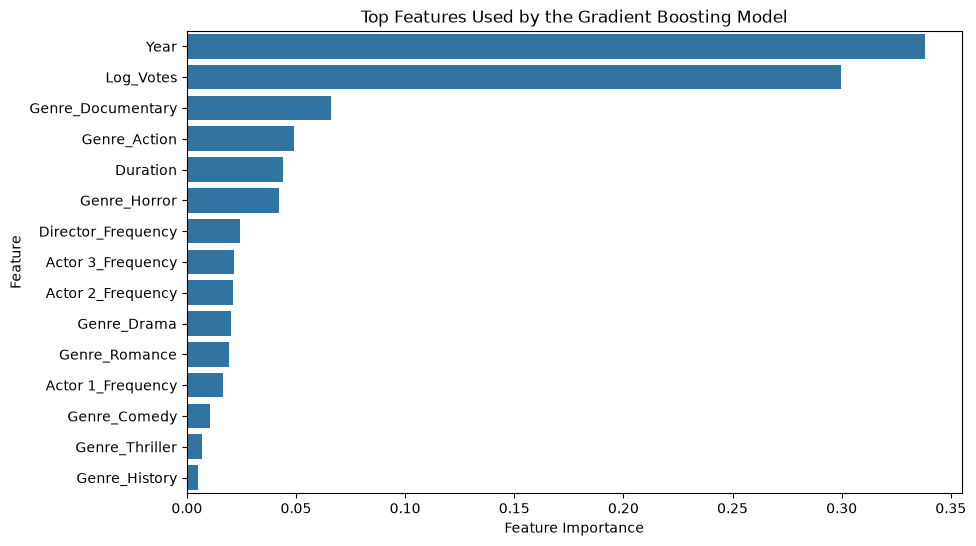

===== TOP FEATURE IMPORTANCE =====


,Feature,Importance
0,Year,0.3382
1,Log_Votes,0.2998
2,Genre_Documentary,0.0663
3,Genre_Action,0.0492
4,Duration,0.0442
5,Genre_Horror,0.0421
6,Director_Frequency,0.0245
7,Actor 3_Frequency,0.0214
8,Actor 2_Frequency,0.0210
9,Genre_Drama,0.0201


In [27]:
feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top Features Used by the Gradient Boosting Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

print("===== TOP FEATURE IMPORTANCE =====")

display(
    top_features.round(4)
)

## 10. Explainable AI with SHAP

Feature importance shows which features are generally useful to the model, but it does not explain how individual features contribute to specific predictions.

SHAP (SHapley Additive exPlanations) is used to explain the Gradient Boosting model. SHAP estimates how each feature pushes a prediction higher or lower relative to a baseline prediction.

The analysis will include:

- Global feature importance using SHAP values
- The overall direction and effect of important features
- An explanation of an individual movie prediction

SHAP values explain the behavior of the trained prediction model and should not be interpreted as causal effects on IMDb ratings.

In [29]:
import shap

# Use a reproducible sample from the test set
shap_sample = X_test_processed.sample(
    n=min(500, len(X_test_processed)),
    random_state=42
)

# Create the SHAP explainer
explainer = shap.Explainer(
    final_model,
    X_train_processed
)

# Calculate SHAP values
shap_values = explainer(
    shap_sample
)

print("===== SHAP EXPLAINER =====")
print("Movies Explained :", shap_sample.shape[0])
print("Features Explained:", shap_sample.shape[1])
print("SHAP Values Shape:", shap_values.values.shape)

c:\Users\yoges\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===== SHAP EXPLAINER =====
Movies Explained : 500
Features Explained: 30
SHAP Values Shape: (500, 30)


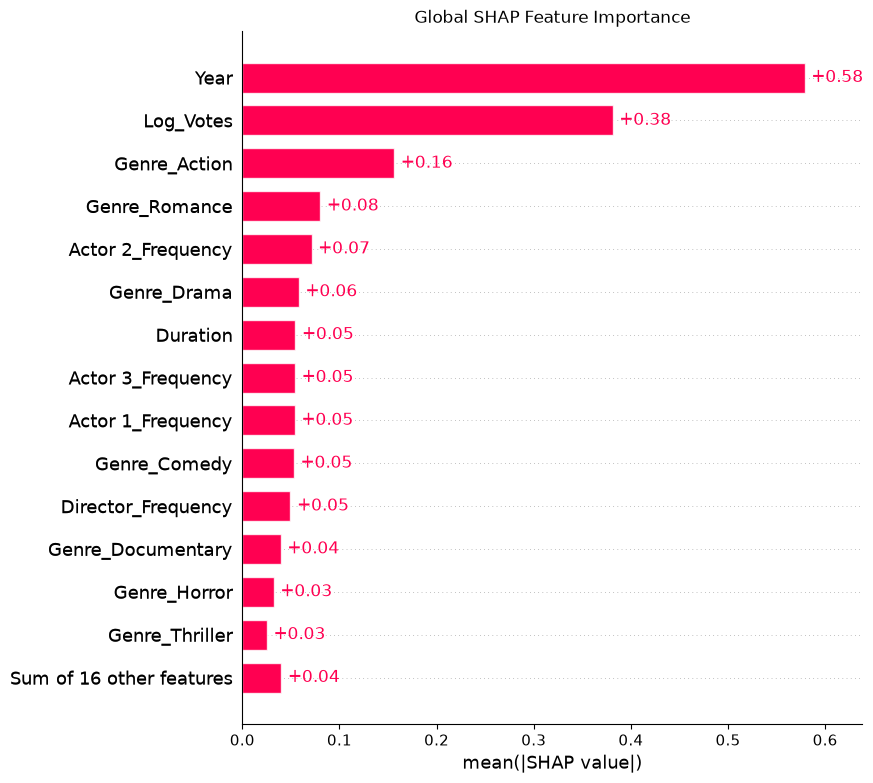

In [30]:
# Global SHAP feature importance
shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title('Global SHAP Feature Importance')
plt.show()

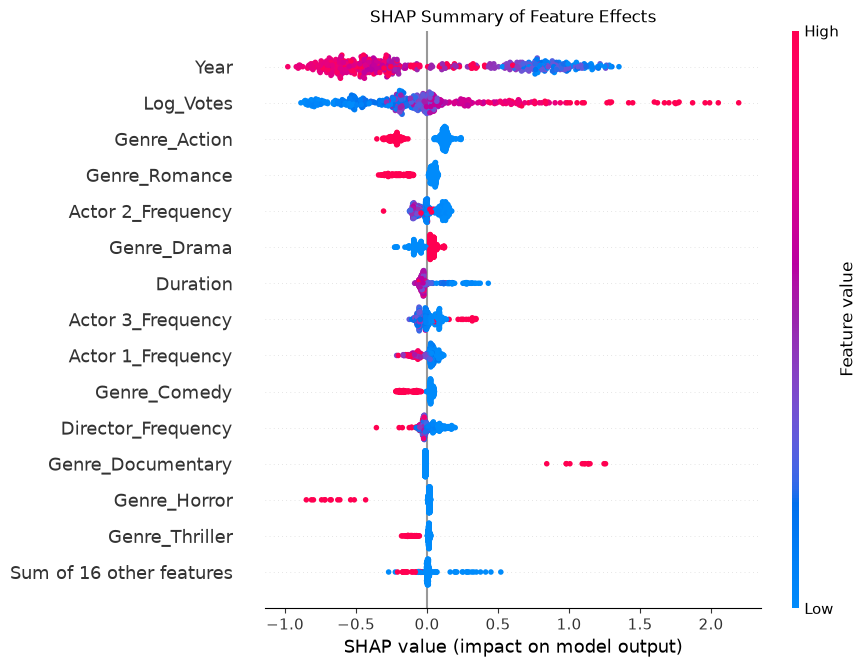

In [31]:
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title('SHAP Summary of Feature Effects')
plt.show()

===== INDIVIDUAL MOVIE EXPLANATION =====
Movie            : Aloo Chaat
Actual Rating    : 5.8
Predicted Rating : 5.09


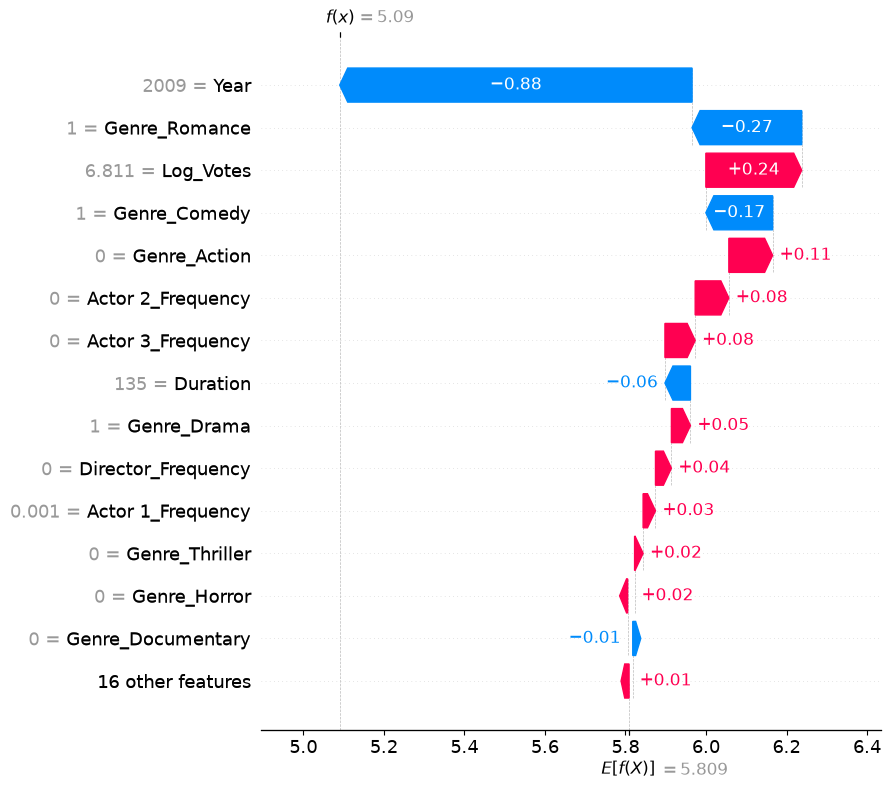

In [32]:
# Select one movie from the SHAP sample
movie_position = 0

movie_index = shap_sample.index[movie_position]

movie_name = rated_movies.loc[
    movie_index,
    'Name'
]

actual_rating = rated_movies.loc[
    movie_index,
    'Rating'
]

predicted_rating = final_model.predict(
    shap_sample.iloc[[movie_position]]
)[0]

print("===== INDIVIDUAL MOVIE EXPLANATION =====")
print("Movie            :", movie_name)
print("Actual Rating    :", round(actual_rating, 2))
print("Predicted Rating :", round(predicted_rating, 2))

shap.plots.waterfall(
    shap_values[movie_position],
    max_display=15
)

In [33]:
movie_shap = pd.DataFrame({
    'Feature': shap_sample.columns,
    'Feature_Value': shap_sample.iloc[movie_position].values,
    'SHAP_Value': shap_values[movie_position].values
})

movie_shap['Absolute_SHAP'] = (
    movie_shap['SHAP_Value'].abs()
)

movie_shap = (
    movie_shap
    .sort_values(
        'Absolute_SHAP',
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== STRONGEST CONTRIBUTIONS =====")

display(
    movie_shap[
        [
            'Feature',
            'Feature_Value',
            'SHAP_Value'
        ]
    ]
    .head(10)
    .round(3)
)

===== STRONGEST CONTRIBUTIONS =====


,Feature,Feature_Value,SHAP_Value
0,Year,2009.000,-0.875
1,Genre_Romance,1.000,-0.272
2,Log_Votes,6.811,0.238
3,Genre_Comedy,1.000,-0.166
4,Genre_Action,0.000,0.109
5,Actor 2_Frequency,0.000,0.084
6,Actor 3_Frequency,0.000,0.075
7,Duration,135.000,-0.063
8,Genre_Drama,1.000,0.047
9,Director_Frequency,0.000,0.040


## 11. Save the Trained Model and Preprocessing Artifacts

To use the trained model outside the notebook, the final Gradient Boosting model and the preprocessing information required for new movie data are saved as reusable artifacts.

The saved preprocessing information includes the training duration median, category frequency mappings, genre list, and final model feature order. These artifacts will later allow the Streamlit application to transform new movie information in the same way as the training data.

In [34]:
frequency_maps = {}

for column in [
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]:
    frequency_maps[column] = (
        X_train[column]
        .value_counts(normalize=True)
        .to_dict()
    )

print("===== PREPROCESSING ARTIFACTS =====")
print("Duration Median :", duration_median)
print("Number of Genres:", len(training_genres))
print("Final Features  :", len(X_train_processed.columns))

print("\nFrequency Maps Saved For:")
print(list(frequency_maps.keys()))

===== PREPROCESSING ARTIFACTS =====
Duration Median : 135.0
Number of Genres: 23
Final Features  : 30

Frequency Maps Saved For:
['Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [ ]:
import joblib
import os

# Models folder is in the project root
MODEL_DIR = "../models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

preprocessing_artifacts = {
    'duration_median': duration_median,
    'frequency_maps': frequency_maps,
    'training_genres': training_genres,
    'feature_columns': X_train_processed.columns.tolist()
}

model_path = os.path.join(
    MODEL_DIR,
    "movie_rating_model.pkl"
)

artifacts_path = os.path.join(
    MODEL_DIR,
    "preprocessing_artifacts.pkl"
)

# Save final model
joblib.dump(
    final_model,
    model_path
)

# Save preprocessing information
joblib.dump(
    preprocessing_artifacts,
    artifacts_path
)

print("===== ARTIFACTS SAVED =====")
print("Model       :", model_path)
print("Preprocessor:", artifacts_path)

print(
    "\nModel Exists:",
    os.path.exists(model_path)
)

print(
    "Preprocessor Exists:",
    os.path.exists(artifacts_path)
)

===== ARTIFACTS SAVED =====
Model       : models/movie_rating_model.pkl
Preprocessor: models/preprocessing_artifacts.pkl

Model Exists: True
Preprocessor Exists: True


In [ ]:
loaded_model = joblib.load(
    model_path
)

loaded_artifacts = joblib.load(
    artifacts_path
)

# Test with one processed movie
test_movie = X_test_processed.iloc[[0]]

original_prediction = final_model.predict(
    test_movie
)[0]

loaded_prediction = loaded_model.predict(
    test_movie
)[0]

print("===== SAVED ARTIFACT VALIDATION =====")

print(
    "Original Model Prediction:",
    round(original_prediction, 4)
)

print(
    "Loaded Model Prediction  :",
    round(loaded_prediction, 4)
)

print(
    "Predictions Match:",
    np.isclose(
        original_prediction,
        loaded_prediction
    )
)

print("\nSaved Artifact Keys:")
print(loaded_artifacts.keys())

print(
    "\nSaved Feature Count:",
    len(loaded_artifacts['feature_columns'])
)

===== SAVED ARTIFACT VALIDATION =====
Original Model Prediction: 4.8624
Loaded Model Prediction  : 4.8624
Predictions Match: True

Saved Artifact Keys:
dict_keys(['duration_median', 'frequency_maps', 'training_genres', 'feature_columns'])

Saved Feature Count: 30


## 12. Interactive Application

The trained model will now be connected to a simple Streamlit application.

The application will allow a user to enter movie characteristics such as release year, duration, genres, director, actors, and vote count. These inputs will be transformed using the same preprocessing information learned during model training and then passed to the saved Gradient Boosting model.

The application will display an estimated IMDb rating and provide a simple explanation of the prediction.